In [1]:
import os
import pandas as pd
import tensorflow as tf
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report, balanced_accuracy_score
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
IMAGE_SIZE = (128, 128)

def load_and_preprocess(file_path, label):
    image_binary = tf.io.read_file(file_path)
    image_tf = tf.image.decode_jpeg(image_binary, channels=3)
    image = tf.image.resize(image_tf, IMAGE_SIZE)
    image = tf.cast(image, tf.float32) / 255.0

    return image, label

In [4]:
BATCH_SIZE = 1024
BASE_DIR = '/content/drive/MyDrive/MDC_data/images/'

Lendo dados de treino

In [5]:
train_info = pd.read_csv("/content/drive/MyDrive/MDC_data/train.csv")

train_file_paths = [os.path.join(BASE_DIR, f'{img_path}') for img_path in train_info['path']]

y_train = train_info['target'].values

train_path_ds = tf.data.Dataset.from_tensor_slices((tf.constant(train_file_paths), tf.constant(y_train)))
train_images_ds = train_path_ds.map(load_and_preprocess,
                       num_parallel_calls=tf.data.AUTOTUNE)

train_batches = train_images_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [6]:
classes = np.unique(y_train)


weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))

Lendo dados de validação

In [7]:
val_info = pd.read_csv("/content/drive/MyDrive/MDC_data/val.csv")

val_file_paths = [os.path.join(BASE_DIR, f'{img_path}') for img_path in val_info['path']]

y_val = val_info['target'].values

val_path_ds = tf.data.Dataset.from_tensor_slices((tf.constant(val_file_paths), tf.constant(y_val)))
val_images_ds = val_path_ds.map(load_and_preprocess,
                       num_parallel_calls=tf.data.AUTOTUNE)

val_batches = val_images_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [8]:
def baseline_cnn(input_shape, num_classes):
    model = Sequential([
        Conv2D(filters=8, kernel_size=(3, 3), activation='relu', input_shape=input_shape),
        MaxPooling2D(pool_size=(2, 2)),
        Flatten(),
#        Dense(units=64, activation='relu'),
        Dense(units=num_classes, activation='softmax')
    ])
    return model

INPUT_SHAPE = (224, 224, 3)
NUM_CLASSES = 2
EPOCHS = 5

cnn_model = baseline_cnn(INPUT_SHAPE, NUM_CLASSES)

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 8)    │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 98568)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │       197,138 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 197,362 (770.95 KB)

 Trainable params: 197,362 (770.95 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

history = cnn_model.fit(
    train_batches,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=val_batches
)

loss, acc = cnn_model.evaluate(val_batches, verbose=0)

Epoch 1/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 2980s 76s/step - accuracy: 0.7192 - loss: 1.2747 - val_accuracy: 0.8280 - val_loss: 0.4527
Epoch 2/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 65s 2s/step - accuracy: 0.8244 - loss: 0.4479 - val_accuracy: 0.8316 - val_loss: 0.4161
Epoch 3/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 86s 2s/step - accuracy: 0.8290 - loss: 0.4118 - val_accuracy: 0.8300 - val_loss: 0.4144
Epoch 4/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 78s 2s/step - accuracy: 0.8353 - loss: 0.3959 - val_accuracy: 0.8256 - val_loss: 0.4141
Epoch 5/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.8389 - loss: 0.3923 - val_accuracy: 0.8212 - val_loss: 0.4286


In [ ]:
import os

MODEL_SAVE_PATH = 'baseline.keras'
cnn_model.save(MODEL_SAVE_PATH)

print(f"Modelo salvo com sucesso em: {MODEL_SAVE_PATH}")

In [ ]:
def  plot_loss_accuracy(hist):
  plt.figure(figsize=(7,5))
  plt.plot(hist.history['loss'], label='train loss')
  plt.plot(hist.history['val_loss'], label='val loss')
  plt.title('Loss')
  plt.xlabel('Épocas'); plt.ylabel('Loss'); plt.legend(); plt.show()

  plt.figure(figsize=(7,5))
  plt.plot(hist.history['accuracy'], label='train acc')
  plt.plot(hist.history['val_accuracy'], label='val acc')
  plt.title('Accuracy')
  plt.xlabel('Épocas'); plt.ylabel('Acurácia'); plt.legend(); plt.show()

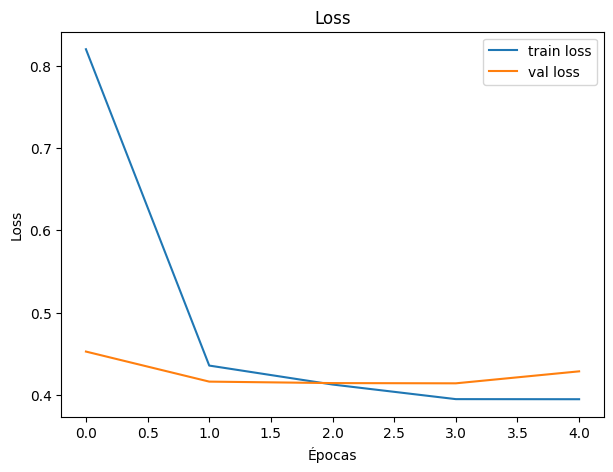

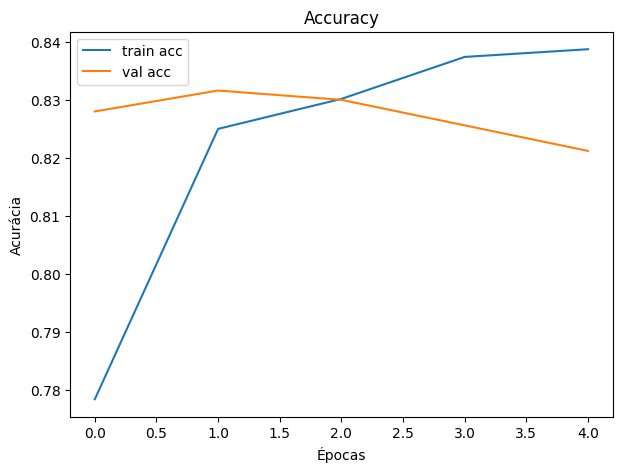

In [ ]:
plot_loss_accuracy(history)

### **Avaliação do modelo treinado**

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, balanced_accuracy_score

In [ ]:
def  plot_confusion_matrix(y_true, y_pred, class_names, NUM_CLASSES=4):
  cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES))).astype("float")
  cm = cm / cm.sum(axis=1, keepdims=True)

  plt.figure(figsize=(6,5))
  sns.heatmap(
        cm,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        cbar=True,
        linewidths=.5,
        linecolor='black'
    )

  plt.title("Matriz de Confusão Normalizada")
  ticks = np.arange(NUM_CLASSES)
  plt.xticks(ticks + 0.5, class_names, rotation=45, ha="right")
  plt.yticks(ticks + 0.5, class_names, rotation=0)
  plt.ylabel("Verdadeiro")
  plt.xlabel("Predito")
  plt.tight_layout()
  plt.show()

Desempenho no conjunto de treino:

40/40 ━━━━━━━━━━━━━━━━━━━━ 68s 2s/step
Train Set Balanced Accuracy: 0.6074213779192651
              precision    recall  f1-score   support

           0       0.86      0.98      0.91     16711
           1       0.72      0.23      0.35      3620

    accuracy                           0.85     20331
   macro avg       0.79      0.61      0.63     20331
weighted avg       0.83      0.85      0.81     20331



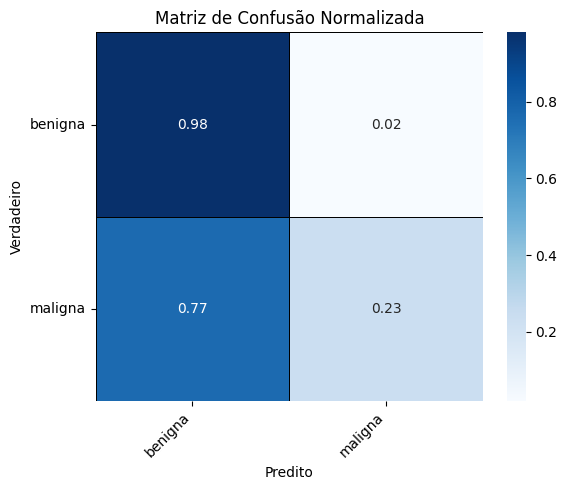

In [ ]:
train_pred = cnn_model.predict(train_batches)
train_pred = np.argmax(train_pred, axis=1)

bal_acc_train = balanced_accuracy_score(y_train, train_pred)
print('=='*10)
print(f'Train Set Balanced Accuracy: {bal_acc_train}')
print('=='*10)

train_report = classification_report(y_train, train_pred)
print(train_report)

plot_confusion_matrix(y_train, train_pred, ['benigna', 'maligna'], NUM_CLASSES)

Desempenho no conjunto de validação:

5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step
Validation Set Balanced Accuracy: 0.5668295697112684
              precision    recall  f1-score   support

           0       0.85      0.95      0.90      2070
           1       0.45      0.18      0.26       430

    accuracy                           0.82      2500
   macro avg       0.65      0.57      0.58      2500
weighted avg       0.78      0.82      0.79      2500



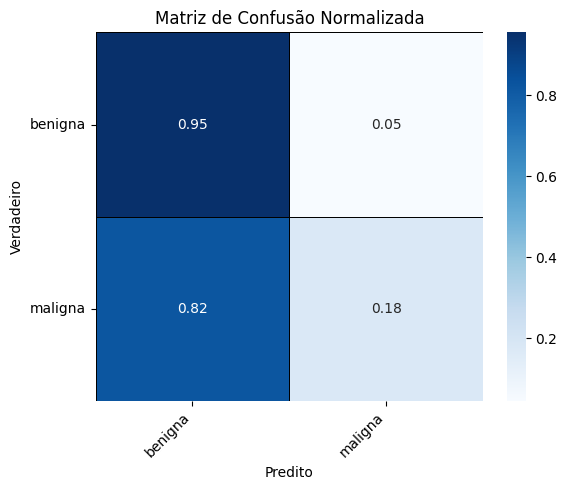

In [ ]:
val_pred = cnn_model.predict(val_batches)
val_pred = np.argmax(val_pred, axis=1)

bal_acc_val = balanced_accuracy_score(y_val, val_pred)
print('=='*10)
print(f'Validation Set Balanced Accuracy: {bal_acc_val}')
print('=='*10)

val_report = classification_report(y_val, val_pred)
print(val_report)

plot_confusion_matrix(y_val, val_pred, ['benigna', 'maligna'], NUM_CLASSES)

In [ ]:
rotulos_dict = {
    0:'benigna',
    1:'maligna'
}

val_iterator = iter(val_batches)

imagens_batch_1, rotulos_batch_1 = next(val_iterator)

x1 = imagens_batch_1[0]
y1 = rotulos_batch_1[0]

print(f"Shape do batch: {imagens_batch_1.shape}")
print(f"Shape da imagem: {x1.shape}")
print(f"Rótulo: {rotulos_dict[int(y1)]}")

Shape do batch: (512, 224, 224, 3)
Shape da imagem: (224, 224, 3)
Rótulo: benigna


In [ ]:
rotulos_dict = {
    0: 'benigna',
    1: 'maligna'
}

imagens_por_classe = {
    0: None,
    1: None
}

classes_a_encontrar = list(imagens_por_classe.keys())
classes_encontradas = 0

val_iterator = iter(val_batches)

while classes_encontradas < len(classes_a_encontrar):
      imagens_batch, rotulos_batch_int = next(val_iterator)

      if rotulos_batch_int.dtype != np.int_:
            rotulos_batch_int = rotulos_batch_int.astype(int)

      for i in range(imagens_batch.shape[0]):
          imagem_candidata = imagens_batch[i]
          rotulo_candidato_int = int(rotulos_batch_int[i])

          if imagens_por_classe[rotulo_candidato_int] is None:
              imagens_por_classe[rotulo_candidato_int] = imagem_candidata
              classes_encontradas += 1

              if classes_encontradas == len(classes_a_encontrar):
                  break

      if classes_encontradas == len(classes_a_encontrar):
          break



### **GradCam**

In [ ]:
# @title
from tensorflow import keras
import matplotlib as mpl

def get_img_array(img_path, size):
  '''
  Carrega uma imagem a partir de um endereço, transforma em um array e em um batch.
  Espera uma imagem colorida (3 canais).
  '''
  # `img` é uma imagem PIL de tamanho 299x299
  img = keras.utils.load_img(img_path, target_size=size)
  # `array` é um array Numpy float32 com forma (299, 299, 3)
  array = keras.utils.img_to_array(img)
  # Adicionamos uma dimensão para transformar nosso array em um "batch"
  # de tamanho (1, 299, 299, 3)
  array = np.expand_dims(array, axis=0)

  return array

def unwrap_model(model, last_conv_layer_name, base_model_name):
  '''
  Essa função extrai os outputs de um modelo aninhado dentro do modelo principal.
  Por exemplo: caso o modelo utilize uma resnet como extrator de características,
  se a ultima camada convolucional for do modelo da resnet, 'last_conv_layer_name'
  apenas será visível a partir do modelo aninhado.
  '''
  n_model = model.get_layer(base_model_name)
  n_model_conv_out = n_model.get_layer(last_conv_layer_name).output
  inp = n_model.input

  # Executa o resto da rede, supondo que o modelo base era a primeira camada
  other_layers = model.layers[1:]
  curr_out = n_model_conv_out
  for layer in other_layers:
    curr_out = layer(curr_out)

  return tf.keras.models.Model(inp, [n_model_conv_out, curr_out])

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None, base_model_name=None):
  # Primeiro, criamos um modelo que mapeia a imagem de entrada para as ativações
  # da última camada convolucional, bem como as previsões de saída
  # Caso o modelo utilize um outro modelo pré treinado (fine-tunning), e sua ultima
  # camada convolucional esteja dentro deste modelo, usamos o parâmetro base_model_name
  # para criarmos o modelo do GradCAM.
  if  base_model_name is None:
    grad_model = keras.models.Model(
        model.inputs, [model.get_layer(last_conv_layer_name).output, model.layers[-1].output]
    )
  else:
    grad_model = unwrap_model(model, last_conv_layer_name, base_model_name)

  # Em seguida, computamos o gradiente da classe prevista no topo para nossa imagem de entrada
  # em relação às ativações da última camada convolucional
  with tf.GradientTape() as tape:
      last_conv_layer_output, preds = grad_model(img_array)
      if pred_index is None:
          pred_index = tf.argmax(preds[0])
      class_channel = preds[:, pred_index]

  # Este é o gradiente do neurônio de saída (mais previsto ou escolhido)
  # em relação ao mapa de características de saída da última camada convolucional
  grads = tape.gradient(class_channel, last_conv_layer_output)

  # Este é um vetor onde cada entrada é a intensidade média do gradiente
  # sobre um canal específico do mapa de características
  pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

  # Multiplicamos cada canal no array do mapa de características
  # por "quão importante esse canal é" em relação à classe prevista no topo
  # e então somamos todos os canais para obter o mapa de calor de ativação da classe
  last_conv_layer_output = last_conv_layer_output[0]
  heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
  heatmap = tf.squeeze(heatmap)

  # Para fins de visualização, também normalizamos o mapa de calor entre 0 e 1
  heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
  return heatmap.numpy()

def denormalize_imagenet_image(normalized_img_np: np.ndarray) -> np.ndarray:
  """
  Reverses the ImageNet normalization process on a single image.
  Formula: original = (normalized * std) + mean

  Args:
      normalized_img_np: A NumPy array (H, W, C) with values normalized
                          using ImageNet mean/std.

  Returns:
      np.ndarray: The image array scaled to [0, 255] and cast to np.uint8.
  """
  # Reshape constants to (1, 1, 3) for broadcasting
  mean = IMAGENET_MEAN.numpy().reshape(1, 1, 3)
  std = IMAGENET_STD.numpy().reshape(1, 1, 3)

  # Reverse normalization: (normalized * std) + mean
  denormalized_img = (normalized_img_np * std) + mean

  # Rescale to [0, 255] and clip to handle minor floating point errors
  denormalized_img = np.clip(denormalized_img * 255.0, 0, 255)

  return denormalized_img.astype(np.uint8)

def show_heatmap_with_image(img, heatmap, alpha=0.5, denormalize_img=True):
  '''
  Mostra uma imagem junto de seu mapa de calor (heatmap).
  O parâmetro alpha controla a opacidade do mapa de calor.
  '''
  # Redimensionar o mapa de calor e imagem para o intervalo de 0 a 255
  heatmap = np.uint8(255 * heatmap)

  if denormalize_img:
    img = denormalize_imagenet_image(img)

  # Usar o mapa de cores 'jet' para colorir o mapa de calor
  jet = mpl.colormaps["jet"]

  # Usar os valores RGB do mapa de cores
  jet_colors = jet(np.arange(256))[:, :3]
  jet_heatmap = jet_colors[heatmap]

  # Criar uma imagem com o mapa de calor colorizado em RGB
  jet_heatmap = keras.utils.array_to_img(jet_heatmap)
  jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
  jet_heatmap = keras.utils.img_to_array(jet_heatmap)

  # Sobrepor o mapa de calor na imagem original
  superimposed_img = jet_heatmap * alpha + img
  superimposed_img = keras.utils.array_to_img(superimposed_img)

  plt.figure(figsize=(12, 6))
  plt.imshow(superimposed_img, cmap="jet")
  plt.title("Grad-CAM Heatmap")
  plt.grid(False)
  plt.axis('off')
  plt.colorbar()
  plt.show()

Classe: benigna
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Pred: benigna


/tmp/ipython-input-2061412335.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pred_class = int(np.argmax(pred, axis=1))
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


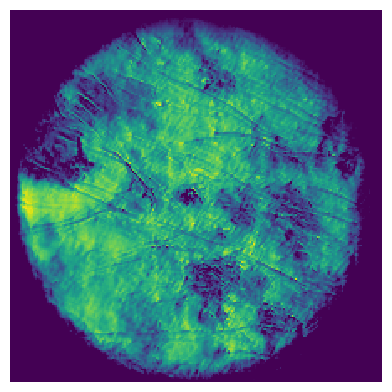

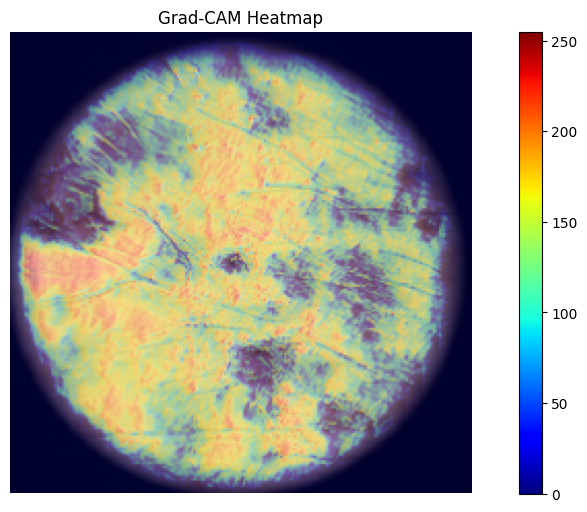

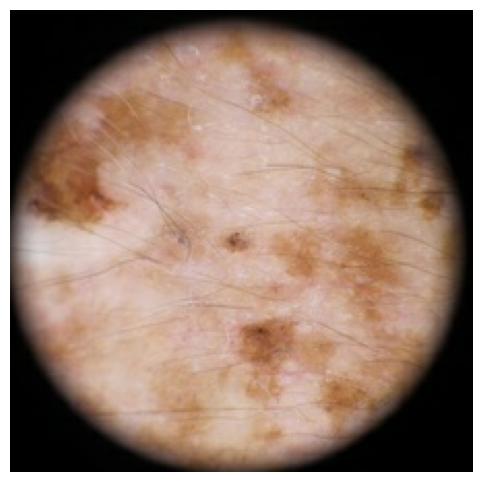

Classe: maligna
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Pred: benigna


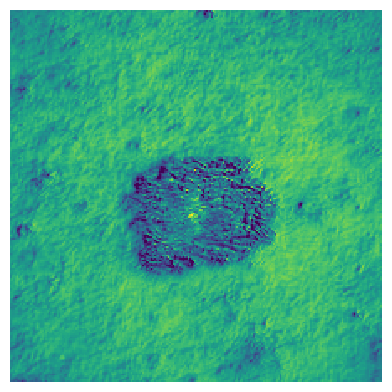

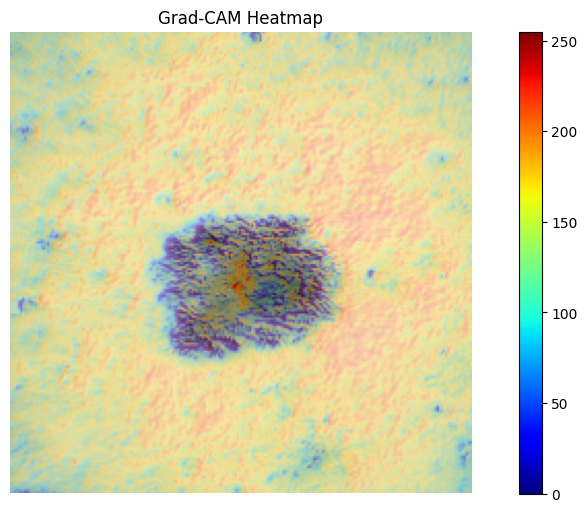

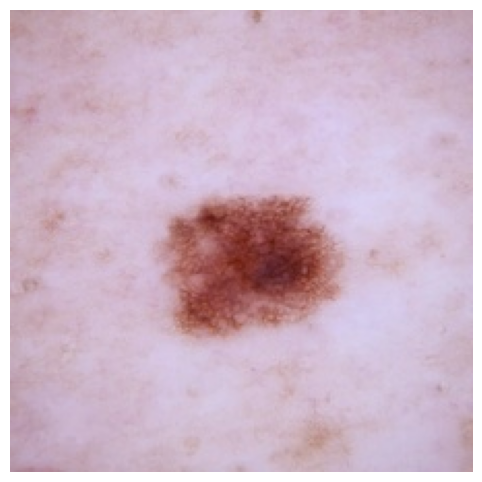

In [ ]:
for classe in [0,1]:
  print('='*30)
  print(f"Classe: {rotulos_dict[classe]}")
  pred = cnn_model.predict(np.expand_dims(imagens_por_classe[classe], axis=0))
  pred_class = int(np.argmax(pred, axis=1))
  print(f"Pred: {rotulos_dict[pred_class]}")

  heatmap = make_gradcam_heatmap(
        np.expand_dims(imagens_por_classe[classe], axis=0),
        cnn_model,
        'conv2d',
        #pred_index=0
    )

  plt.matshow(heatmap)
  plt.grid(False)
  plt.axis('off')
  plt.show()

  show_heatmap_with_image((255*imagens_por_classe[classe]), heatmap, denormalize_img=False)

  plt.figure(figsize=(12, 6))
  plt.imshow(imagens_por_classe[classe])
  plt.grid(False)
  plt.axis('off')
  plt.show()
  print('='*30)

## Variações de Arquitetura de Modelos

In [9]:
def cnn_v1(input_shape, num_classes):
    model = Sequential([
        Conv2D(filters=8, kernel_size=(32, 32), activation='relu', input_shape=input_shape),
        MaxPooling2D(pool_size=(2, 2)),
        Conv2D(filters=8, kernel_size=(16, 16), activation='relu', input_shape=input_shape),
        MaxPooling2D(pool_size=(2, 2)),
        Flatten(),
        Dense(units=num_classes, activation='softmax')
    ])
    return model

INPUT_SHAPE = (128, 128, 3)
NUM_CLASSES = 2
EPOCHS =10
cnn_model_1 = cnn_v1(INPUT_SHAPE, NUM_CLASSES)

cnn_model_1.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model_1.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 97, 97, 8)      │        24,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 48, 48, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 33, 33, 8)      │        16,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │         4,098 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,074 (176.07 KB)

 Trainable params: 45,074 (176.07 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
from tensorflow.keras.mixed_precision import set_global_policy
set_global_policy('mixed_float16')

In [ ]:
history = cnn_model_1.fit(
    train_batches,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=val_batches
)


Epoch 1/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 1830s 92s/step - accuracy: 0.7072 - loss: 0.5779 - val_accuracy: 0.8280 - val_loss: 0.4590
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 69s 3s/step - accuracy: 0.8229 - loss: 0.4611 - val_accuracy: 0.8276 - val_loss: 0.4451
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 70s 4s/step - accuracy: 0.8232 - loss: 0.4467 - val_accuracy: 0.8280 - val_loss: 0.4418
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 82s 3s/step - accuracy: 0.8232 - loss: 0.4443 - val_accuracy: 0.8280 - val_loss: 0.4290
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 70s 3s/step - accuracy: 0.8248 - loss: 0.4311 - val_accuracy: 0.8284 - val_loss: 0.4265
Epoch 6/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 69s 3s/step - accuracy: 0.8254 - loss: 0.4254 - val_accuracy: 0.8292 - val_loss: 0.4256
Epoch 7/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 70s 3s/step - accuracy: 0.8265 - loss: 0.4258 - val_accuracy: 0.8280 - val_loss: 0.4253
Epoch 8/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 69s 3s/step - accuracy: 0.8254 - loss: 0.4239 - val_accuracy: 0.8292 - val_lo

In [ ]:
def training(model,
             train_dataset,
             val_dataset,
             batch_size,
             epochs):

    history = model.fit(
        train_dataset,
        batch_size=batch_size,
        epochs=epochs,
        validation_data=val_dataset
    )

    plot_loss_accuracy(history)

    return history

In [ ]:
def predict_and_evaluate(model, train_dataset, y_train, val_dataset = None, y_val = None):
  train_pred = model.predict(train_dataset)
  train_pred = np.argmax(train_pred, axis=1)
  bal_acc_train = balanced_accuracy_score(y_train, train_pred)

  print('=='*10)
  print(f'Train Set Balanced Accuracy: {bal_acc_train}')
  print('=='*10)

  train_report = classification_report(y_train, train_pred)
  print(train_report)
  plot_confusion_matrix(y_train, train_pred, ['benigna', 'maligna'], NUM_CLASSES)

  if val_dataset is not None and y_val is not None:
        val_pred = model.predict(val_dataset)
        val_pred = np.argmax(val_pred, axis=1)
        bal_acc_val = balanced_accuracy_score(y_val, val_pred)
        print('=='*10)
        print(f'Validation Set Balanced Accuracy: {bal_acc_val}')
        print('=='*10)

        val_report = classification_report(y_val, val_pred)
        print(val_report)
        plot_confusion_matrix(y_val, val_pred, ['benigna', 'maligna'], NUM_CLASSES)

        return train_pred, bal_acc_train, train_report, val_pred, bal_acc_val, val_report

  return train_pred, bal_acc_train, train_report

20/20 ━━━━━━━━━━━━━━━━━━━━ 62s 3s/step
Train Set Balanced Accuracy: 0.5173921898137693
              precision    recall  f1-score   support

           0       0.83      1.00      0.90     16711
           1       0.68      0.04      0.07      3620

    accuracy                           0.83     20331
   macro avg       0.76      0.52      0.49     20331
weighted avg       0.80      0.83      0.76     20331



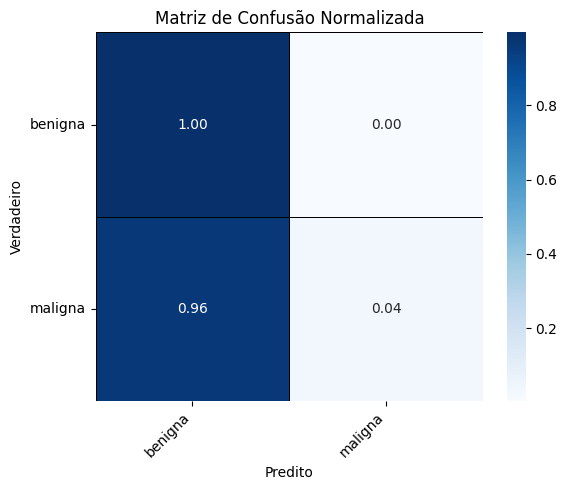

3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step
Validation Set Balanced Accuracy: 0.5177901359397821
              precision    recall  f1-score   support

           0       0.83      0.99      0.91      2070
           1       0.58      0.04      0.08       430

    accuracy                           0.83      2500
   macro avg       0.71      0.52      0.49      2500
weighted avg       0.79      0.83      0.76      2500



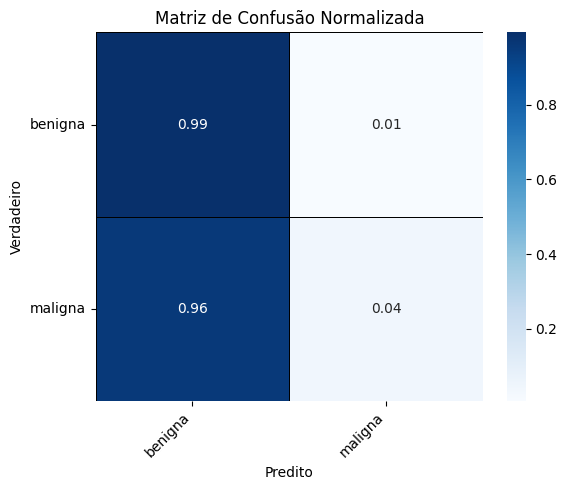

(array([0, 0, 0, ..., 0, 0, 0]),
 np.float64(0.5173921898137693),
 '              precision    recall  f1-score   support\n\n           0       0.83      1.00      0.90     16711\n           1       0.68      0.04      0.07      3620\n\n    accuracy                           0.83     20331\n   macro avg       0.76      0.52      0.49     20331\nweighted avg       0.80      0.83      0.76     20331\n',
 array([0, 0, 0, ..., 0, 0, 0]),
 np.float64(0.5177901359397821),
 '              precision    recall  f1-score   support\n\n           0       0.83      0.99      0.91      2070\n           1       0.58      0.04      0.08       430\n\n    accuracy                           0.83      2500\n   macro avg       0.71      0.52      0.49      2500\nweighted avg       0.79      0.83      0.76      2500\n')

In [ ]:
predict_and_evaluate(cnn_model_1, train_batches, y_train, val_batches, y_val)

In [40]:
cnn_model_2 = cnn_v1(INPUT_SHAPE, NUM_CLASSES)

cnn_model_2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [41]:
history_v2 = cnn_model_2.fit(
    train_batches,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=val_batches
)


Epoch 1/10
 5/20 ━━━━━━━━━━━━━━━━━━━━ 12s 831ms/step - accuracy: 0.4849 - loss: 0.7198

KeyboardInterrupt: 

20/20 ━━━━━━━━━━━━━━━━━━━━ 62s 3s/step
Train Set Balanced Accuracy: 0.5
              precision    recall  f1-score   support

           0       0.82      1.00      0.90     16711
           1       0.00      0.00      0.00      3620

    accuracy                           0.82     20331
   macro avg       0.41      0.50      0.45     20331
weighted avg       0.68      0.82      0.74     20331



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


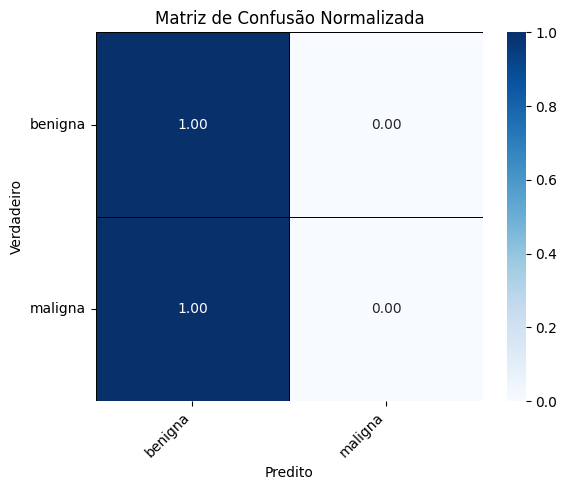

3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step
Validation Set Balanced Accuracy: 0.5
              precision    recall  f1-score   support

           0       0.83      1.00      0.91      2070
           1       0.00      0.00      0.00       430

    accuracy                           0.83      2500
   macro avg       0.41      0.50      0.45      2500
weighted avg       0.69      0.83      0.75      2500



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


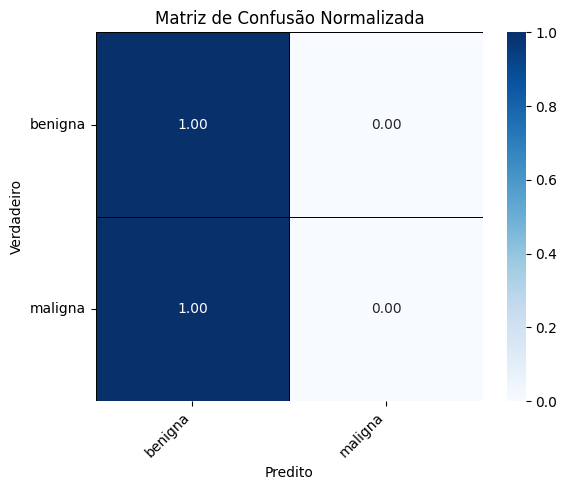

(array([0, 0, 0, ..., 0, 0, 0]),
 np.float64(0.5),
 '              precision    recall  f1-score   support\n\n           0       0.82      1.00      0.90     16711\n           1       0.00      0.00      0.00      3620\n\n    accuracy                           0.82     20331\n   macro avg       0.41      0.50      0.45     20331\nweighted avg       0.68      0.82      0.74     20331\n',
 array([0, 0, 0, ..., 0, 0, 0]),
 np.float64(0.5),
 '              precision    recall  f1-score   support\n\n           0       0.83      1.00      0.91      2070\n           1       0.00      0.00      0.00       430\n\n    accuracy                           0.83      2500\n   macro avg       0.41      0.50      0.45      2500\nweighted avg       0.69      0.83      0.75      2500\n')

In [ ]:
predict_and_evaluate(cnn_model_2, train_batches, y_train, val_batches, y_val)

In [59]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, BatchNormalization, Dropout
from tensorflow.keras.models import Sequential

def cnn_v4(input_shape, num_classes):
    model = Sequential([
        Conv2D(filters=16, kernel_size=(3, 3), activation='relu', input_shape=input_shape),
        BatchNormalization(),
        Conv2D(filters=16, kernel_size=(3, 3), activation='relu'),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.1),

        Conv2D(filters=32, kernel_size=(3, 3), activation='relu'),
        BatchNormalization(),
        Conv2D(filters=32, kernel_size=(3, 3), activation='relu'),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.1),

        Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.1),

        Flatten(),
        Dense(units=128, activation='relu'),
        Dropout(0.5),
        Dense(units=num_classes, activation='softmax')
    ])
    return model

In [60]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import numpy as np

def plot_roc_curve(true: np.ndarray, pred: np.ndarray):
    prob_positiva = pred[:, 1]

    fpr, tpr, thresholds = roc_curve(true, prob_positiva)
    roc_auc = auc(fpr, tpr)

    j_scores = tpr - fpr
    j_index = np.argmax(j_scores)

    optimal_threshold = thresholds[j_index]
    plt.figure(figsize=(8, 6))

    # Curva do Modelo
    plt.plot(fpr, tpr, color='darkorange', lw=2,
             label=f'Curva ROC (AUC = {roc_auc:.4f})')

    # Linha de classificação aleatória
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Aleatório')

    # Ponto do threshold ideal
    plt.plot(fpr[j_index], tpr[j_index], 'ro', markersize=8,
             label=f'Threshold Ideal ({optimal_threshold:.4f})')

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Taxa de Falsos Positivos (1 - Especificidade)')
    plt.ylabel('Taxa de Verdadeiros Positivos (Sensibilidade)')
    plt.title('Curva ROC e Threshold Ótimo para Classificador de Melanoma')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

    return optimal_threshold, roc_auc

In [61]:
cnn_model_4 = cnn_v4(INPUT_SHAPE, NUM_CLASSES)

In [62]:
learning_rate = 1e-5
optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

cnn_model_4.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
cnn_model_4.fit(
    train_batches,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=val_batches,
    class_weight={0:1, 1:15}
)

Epoch 1/10
 5/20 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step - accuracy: 0.4446 - loss: 2.1670

In [ ]:
val_prob = cnn_model_4.predict(val_batches)
prob_positiva = val_prob[:, 1]

In [ ]:
optimal_threshold, roc_auc = plot_roc_curve(y_val, val_prob)

In [ ]:
val_pred_adjusted = np.where(prob_positiva > optimal_threshold, 1, 0)

In [ ]:
bal_acc_val_adjusted = balanced_accuracy_score(y_val, val_pred_adjusted)
print(f'Acurácia Balanceada de Validação (Ajustada): {bal_acc_val_adjusted:.4f}\n')

In [ ]:
plot_confusion_matrix(y_val, val_pred_adjusted, ['benigna', 'maligna'], NUM_CLASSES)